In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sys.path.append(os.path.abspath("../src"))
from analytics.kpi_engine import main as run_kpi_engine

In [3]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

In [4]:
run_kpi_engine()

[1/4] Ingesting Cleaned Datasets...
[2/4] Calculating Fleet-Wide OEE & Asset Utilization...
[3/4] Evaluating MTBF, MTTR, and Financial Scrap/Downtime Impact...
[4/4] Generating Temporal Monthly OEE Trends...

Manufacturing KPI Execution Complete.
-----------------------------------------------------------------------------------------
Machine  | OEE (%)  | Avail (%)  | Perf (%)  | Qual (%)  | MTBF (h)  | Cost of Unrel (INR)
-----------------------------------------------------------------------------------------
M01      |   81.61% |     98.52% |    86.53% |    95.74% |     851.2 | Rs.    4,922,203.00
M02      |   81.56% |     98.08% |    86.77% |    95.84% |     706.2 | Rs.    4,987,148.00
M03      |   82.18% |     98.84% |    86.71% |    95.89% |     854.0 | Rs.    4,756,066.00
M04      |   81.24% |     97.96% |    86.68% |    95.67% |     529.0 | Rs.    7,626,511.00
M05      |   81.13% |     98.12% |    86.41% |    95.69% |     605.6 | Rs.    7,290,532.00
M06      |   82.36% |     9

In [5]:
df_kpi = pd.read_parquet("../data/processed/kpis/fleet_kpi_summary.parquet")
df_monthly = pd.read_csv("../data/processed/kpis/monthly_oee_trends.csv")

In [6]:
df_kpi[[
    "machine_id", "machine_name", "availability_pct", "performance_pct", 
    "quality_pct", "oee_pct", "mtbf_hours", "mttr_hours", "total_cost_of_unreliability_inr"
]]

,machine_id,machine_name,availability_pct,performance_pct,quality_pct,oee_pct,mtbf_hours,mttr_hours,total_cost_of_unreliability_inr
0,M01,CNC Lathe 01,98.52,86.53,95.74,81.61,851.2,12.80,4922203.0
1,M02,CNC Milling 01,98.08,86.77,95.84,81.56,706.2,13.83,4987148.0
2,M03,CNC Milling 02,98.84,86.71,95.89,82.18,854.0,10.00,4756066.0
3,M04,Hydraulic Press 01,97.96,86.68,95.67,81.24,529.0,11.00,7626511.0
4,M05,Hydraulic Unit 02,98.12,86.41,95.69,81.13,605.6,11.57,7290532.0
5,M06,Coolant Pump 01,98.45,87.20,95.94,82.36,1063.2,16.75,6745312.0
6,M07,Slurry Pump 02,98.36,86.61,95.85,81.65,708.2,11.83,6907858.0
7,M08,Drive Motor 01,98.63,86.96,95.84,82.20,1065.2,14.75,6984175.0
8,M09,Drive Motor 02,98.89,86.52,95.80,81.97,1068.0,12.00,6973953.0
9,M10,Screw Compressor 01,97.34,86.70,95.65,80.72,525.6,14.38,7805615.0


AttributeError: Rectangle.set() got an unexpected keyword argument 'fontweight'

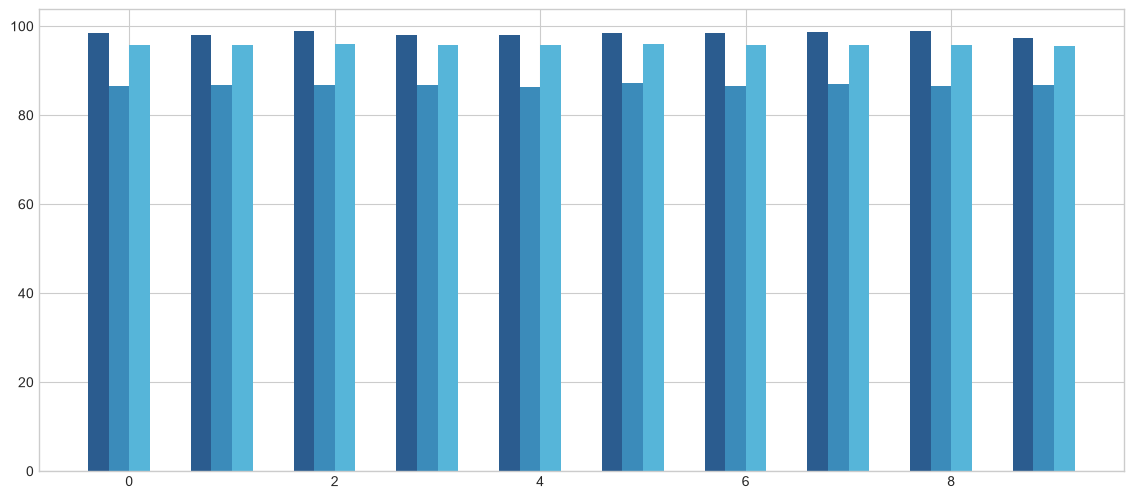

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(df_kpi))
width = 0.2

rects1 = ax.bar(x - 1.5*width, df_kpi["availability_pct"], width, label="Availability (%)", color="#2b5c8f")
rects2 = ax.bar(x - 0.5*width, df_kpi["performance_pct"], width, label="Performance (%)", color="#3b8bba")
rects3 = ax.bar(x + 0.5*width, df_kpi["quality_pct"], width, label="Quality (%)", color="#56b5d9")
rects4 = ax.bar(x + 1.5*width, df_kpi["oee_pct"], width, label="OEE (%)", color="#d95f02")

ax.axhline(85.0, color="green", linestyle="--", linewidth=1.5, label="World Class OEE (85%)")
ax.set_ylabel("Percentage (%)", fontsize=12)
ax.set_title("OEE Decomposition per Asset: Availability vs Performance vs Quality", fontsize=14, pad=12)
ax.set_xticks(x)
ax.set_xticklabels(df_kpi["machine_id"], fontsize=11)
ax.set_ylim(40, 105)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()